In [132]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import config
from data_utils import sort_data

In [133]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [134]:
data.shape

(20337, 104)

In [135]:
data.head()

,position,team_name,match_id,web_name,second_name,first_name,status,player_code,touches_opposition_box,gw,team_code,id,selected_by_percent,ep_this,goals_conceded,threat,expected_assists,fouls_committed,now_cost,xgot,chances_created,penalties_scored,tackles_won,value_season,ict_index,clearances,accurate_passes_percent,blocks,successful_dribbles_percent,xa,creativity,tackles_won_percent,xgot_faced,value_form,selected_rank,influence,penalties_order,successful_dribbles,gk_accurate_long_balls,transfers_in_event,finish_min,accurate_crosses,interceptions,tackles,sweeper_actions,aerial_duels_won_percent,was_fouled,corners_and_indirect_freekicks_order,headed_clearances,bonus,total_points,offsides,duels_lost,form,event_points,accurate_crosses_percent,ground_duels_won,ground_duels_won_percent,start_min,gk_accurate_passes,team_strength,transfers_out,cost_change_event,saves,aerial_duels_won,accurate_passes,goals_prevented,dreamteam_count,bps,expected_goals_conceded,assists,ep_next,transfers_out_event,penalties_missed,duels_won,final_third_passes,dribbled_past,now_cost_rank,recoveries,minutes_played,touches,expected_goal_involvements,chance_of_playing_next_round,cost_change_start,direct_freekicks_order,goals,transfers_in,team_goals_conceded,xg,accurate_long_balls_percent,shots_on_target,big_chances_missed,high_claim,accurate_long_balls,total_shots,chance_of_playing_this_round,expected_goals,season_id,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,was_home,value_ratio
0,MID,Brighton,24-25-prem-everton-vs-brighton-&-hove-albion,Milner,Milner,James,a,15157,2,1,36,134,0.1,1.6,0,4,0.11,1,5.0,0.0,3,0,2,0.4,7.0,0,85,2,0,0.11,43.8,50,0.0,0.4,471,22.4,6,0,0,513,82,2,0,4,0,0,0,1,0,0,2,0,2,2.0,2,29,4,80,0,0,3,421,0,0,0,28,0.0,0,10,0.45,0,1.6,421,0,4,2,0,172,0,82,48,0.11,0,0,7,0,513,0,0.0,33,0,0,0,1,0,0,0.0,2425,0.0,0.120732,0.120732,0.493902,False,0.4
1,MID,Brighton,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Milner,Milner,James,a,15157,2,2,36,134,0.1,2.0,0,12,0.15,1,5.0,0.0,1,0,0,0.8,10.7,2,73,0,100,0.04,66.2,0,0.0,0.4,448,28.6,6,1,0,1189,73,1,1,1,0,0,1,1,0,0,4,0,1,2.0,2,100,3,75,0,0,3,1548,0,0,0,22,0.0,0,22,1.77,0,1.0,635,0,3,6,0,177,2,73,42,0.31,0,0,7,0,2267,1,0.16,0,1,0,0,0,2,0,0.16,2425,0.19726,0.049315,0.382192,2.182192,True,0.4
2,MID,Brighton,24-25-prem-arsenal-vs-brighton-&-hove-albion,Milner,Milner,James,d,15157,0,3,36,134,0.1,0.7,0,12,0.15,1,5.0,0.0,0,0,0,1.0,10.7,0,100,0,0,0.0,66.3,0,0.0,0.3,461,28.6,6,0,0,472,17,0,1,0,0,0,0,1,0,0,5,0,1,1.7,1,0,0,0,0,0,3,4535,0,0,0,2,0.0,0,24,1.98,0,1.7,1998,0,0,0,0,185,0,17,4,0.31,75,0,7,0,4199,0,0.0,0,0,0,0,0,0,0,0.16,2425,0.0,0.0,1.641176,10.482353,False,0.2
3,MID,Brighton,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,Milner,Milner,James,a,15157,0,38,36,134,0.0,0.0,0,12,0.15,0,5.0,0.0,0,0,0,1.2,10.7,0,0,0,0,0.0,66.3,0,0.0,0.0,586,28.6,6,0,0,0,93,0,0,0,0,0,0,8,0,0,6,0,0,0.2,1,0,0,0,93,0,3,10991,0,0,0,0,0.0,0,27,1.98,0,0.0,0,0,0,1,0,192,0,1,1,0.31,100,0,7,0,5014,0,0.0,0,0,0,0,0,0,0,0.16,2425,0.0,0.0,27.9,178.2,False,0.2
4,MID,Brighton,25-26-prem-brighton-hove-albion-vs-fulham,Milner,Milner,James,a,15157,0,1,36,170,0.1,0.0,0,0,0.0,0,4.9,0.0,0,0,0,3.1,0.0,0,0,0,0,0.0,0.1,0,0.0,0.0,467,0.0,1,0,0,113,90,0,0,0,0,0,0,5,0,0,1,0,0,0.0,1,0,0,0,0,0,3,20304,0,0,0,1,0.0,0,3,0.24,0,-0.5,497,0,0,0,0,283,0,2,1,0.0,100,-1,7,0,14413,1,0.0,0,0,0,0,0,0,0,0.0,2526,0.0,0.0,0.0,10.8,True,0.204082


In [136]:
data.isna().sum().sum()

np.int64(0)

In [137]:
data.drop(columns="total_points", inplace=True)

In [138]:
all_cols = set(data.columns)

rules = {
    "target": ["event_points"],
    "cols_id": ['id', 'code', 'name', 'gw', 'season_id', 'match_id', 'team_name'],
    "static_cols": ['position', 'team_strength', "was_home", "status"],
    "order_cols": ['now_cost', 'order', 'chance_of_playing', "rank"],
    "ratio_features": ['percent', 'per_90']
}

categories = {key: [] for key in rules}
remaining_cols = all_cols.copy()

for category, keywords in rules.items():
    matched = [
        c for c in remaining_cols
        if any(k in c for k in keywords)
    ]
    categories[category] = matched
    remaining_cols -= set(matched)

performance_cols = list(remaining_cols) + ["offsides", "touches_opposition_box"]

target = categories["target"]
cols_id = [c for c in categories["cols_id"] if c != "offsides"]
static_cols = [c for c in categories["static_cols"] if c != "touches_opposition_box"]
order_cols = categories["order_cols"]
ratio_features = categories["ratio_features"]


cols_to_lag = performance_cols + categories["order_cols"]
cols_to_ema = performance_cols+order_cols+ratio_features

In [139]:
data.shape[1], len(target + cols_id + static_cols + order_cols + ratio_features + performance_cols)

(103, 103)

In [140]:
performance_cols

['expected_goal_involvements',
 'successful_dribbles',
 'finish_min',
 'headed_clearances',
 'accurate_crosses',
 'ict_index',
 'assists',
 'xgot_faced',
 'big_chances_missed',
 'saves',
 'duels_lost',
 'bonus',
 'tackles_won',
 'influence',
 'transfers_in_event',
 'shots_on_target',
 'gk_accurate_passes',
 'ground_duels_won',
 'value_season',
 'penalties_scored',
 'aerial_duels_won',
 'transfers_in',
 'expected_goals',
 'transfers_out_event',
 'touches',
 'value_form',
 'goals',
 'final_third_passes',
 'threat',
 'gk_accurate_long_balls',
 'tackles',
 'team_goals_conceded',
 'start_min',
 'xgot',
 'cost_change_event',
 'high_claim',
 'accurate_long_balls',
 'total_shots',
 'dribbled_past',
 'expected_goals_conceded',
 'xa',
 'form',
 'chances_created',
 'was_fouled',
 'bps',
 'cost_change_start',
 'goals_prevented',
 'recoveries',
 'xg',
 'clearances',
 'sweeper_actions',
 'penalties_missed',
 'goals_conceded',
 'transfers_out',
 'fouls_committed',
 'expected_assists',
 'blocks',
 'va

In [141]:
pre_game_cols = [
    'selected_by_percent',
    'cost_change_start',
    'cost_change_event',
    'transfers_in',
    'transfers_out',
    'transfers_in_event',
    'transfers_out_event',
    'ep_this',
    'ep_next'
]

In [142]:
def ema(df:pd.DataFrame,
        cols_to_lag:list[str] | None,
        window_size:int=4)->tuple[pd.DataFrame, list[str]]:

    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df)

    ema_frame = df.groupby(["player_code", "season_id"])[cols_to_lag].transform(lambda x: x.ewm(span=window_size, adjust=False).mean().shift(1))

    new_cols = [f"{c}_ema_{window_size}" for c in cols_to_lag]
    df[new_cols] = ema_frame.fillna(0)
    return df, new_cols


In [143]:
def lagged_features(df:pd.DataFrame,
                    cols_to_lag:list[str] | None,
                    lag_size:int=1)->tuple[pd.DataFrame, list[str]]:
    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df)

    lagged_frame = df.groupby(["player_code", "season_id"])[cols_to_lag].transform(lambda x: x.shift(lag_size))
    new_cols = [f"{c}_lagged_{lag_size}" for c in cols_to_lag]
    df[new_cols] = lagged_frame.fillna(0)

    return df, new_cols

In [144]:
data_ema, ema_cols = ema(df=data,
                        cols_to_lag=cols_to_ema+target,
                        window_size=8)


In [145]:
data.shape

(20337, 103)

In [146]:
data_lagged, lagged_cols = lagged_features(df=data_ema,
                        cols_to_lag=cols_to_lag+target)


In [147]:
data_lagged.shape

(20337, 269)

In [148]:
features_to_keep = list(set(
    cols_id +
    static_cols +
    pre_game_cols +
    ema_cols +
    lagged_cols +
    target

))

In [149]:
data_lagged = data_lagged[[c for c in features_to_keep if c in data_lagged.columns]].copy()

In [150]:
data_lagged.shape

(20337, 190)

In [151]:
data_lagged.head()

,creativity_lagged_1,form_lagged_1,transfers_out_lagged_1,second_name,goals_conceded_lagged_1,accurate_passes_ema_8,final_third_passes_lagged_1,ep_this_lagged_1,selected_rank_lagged_1,form_ema_8,first_name,duels_won_ema_8,ict_index_lagged_1,threat_ema_8,transfers_in_event_ema_8,team_name,transfers_in,accurate_crosses_lagged_1,tackles_won_percent_ema_8,ep_next_lagged_1,aerial_duels_won_ema_8,successful_dribbles_percent_ema_8,successful_dribbles_lagged_1,dribbled_past_ema_8,value_season_ema_8,event_points_ema_8,expected_goals_ema_8,expected_goal_involvements_lagged_1,blocks_lagged_1,xg_per_90_ema_8,direct_freekicks_order_lagged_1,transfers_in_event_lagged_1,match_id,was_home,xgot_ema_8,shots_on_target_lagged_1,transfers_in_ema_8,corners_and_indirect_freekicks_order_ema_8,ground_duels_won_lagged_1,dreamteam_count_lagged_1,touches_opposition_box_lagged_1,accurate_long_balls_percent_ema_8,xgot_faced_lagged_1,selected_by_percent_ema_8,cost_change_start_ema_8,gk_accurate_passes_lagged_1,bps_ema_8,high_claim_lagged_1,value_form_lagged_1,shots_on_target_ema_8,chance_of_playing_this_round_ema_8,gw,transfers_out_event_lagged_1,big_chances_missed_ema_8,bonus_ema_8,saves_lagged_1,gk_accurate_long_balls_lagged_1,assists_ema_8,transfers_out_event_ema_8,goals_prevented_ema_8,goals_conceded_ema_8,transfers_out,expected_assists_lagged_1,accurate_long_balls_ema_8,ep_next_ema_8,headed_clearances_ema_8,expected_goals_conceded_ema_8,penalties_missed_lagged_1,expected_goal_involvements_ema_8,value_form_ema_8,accurate_long_balls_lagged_1,successful_dribbles_ema_8,chance_of_playing_next_round_ema_8,interceptions_ema_8,bps_lagged_1,chance_of_playing_this_round_lagged_1,start_min_ema_8,goals_ema_8,team_code,team_goals_conceded_lagged_1,creativity_ema_8,was_fouled_ema_8,xa_per_90_ema_8,duels_lost_ema_8,offsides_lagged_1,ep_this,expected_assists_ema_8,now_cost_lagged_1,id,recoveries_ema_8,penalties_order_ema_8,value_season_lagged_1,aerial_duels_won_lagged_1,start_min_lagged_1,gk_accurate_long_balls_ema_8,ep_this_ema_8,xa_lagged_1,total_shots_ema_8,xg_ema_8,minutes_played_ema_8,touches_lagged_1,finish_min_ema_8,corners_and_indirect_freekicks_order_lagged_1,dribbled_past_lagged_1,value_ratio_lagged_1,was_fouled_lagged_1,chances_created_lagged_1,penalties_missed_ema_8,ict_index_ema_8,selected_by_percent,event_points,value_ratio_ema_8,now_cost_ema_8,now_cost_rank_ema_8,fouls_committed_lagged_1,position,transfers_in_event,expected_goals_conceded_lagged_1,penalties_scored_ema_8,touches_opposition_box_ema_8,influence_ema_8,transfers_out_event,clearances_ema_8,sweeper_actions_lagged_1,chance_of_playing_next_round_lagged_1,accurate_passes_percent_ema_8,total_shots_lagged_1,xgot_faced_ema_8,bonus_lagged_1,ground_duels_won_ema_8,ground_duels_won_percent_ema_8,web_name,assists_lagged_1,team_goals_conceded_ema_8,saves_ema_8,sweeper_actions_ema_8,selected_rank_ema_8,cost_change_event_ema_8,touches_ema_8,goals_lagged_1,cost_change_event,tackles_ema_8,tackles_lagged_1,player_code,big_chances_missed_lagged_1,now_cost_rank_lagged_1,minutes_played_lagged_1,high_claim_ema_8,chances_created_ema_8,cost_change_start,transfers_out_ema_8,accurate_crosses_percent_ema_8,transfers_in_lagged_1,expected_goal_involvements_per_90_ema_8,clearances_lagged_1,season_id,finish_min_lagged_1,duels_lost_lagged_1,cost_change_start_lagged_1,xa_ema_8,goals_prevented_lagged_1,final_third_passes_ema_8,fouls_committed_ema_8,accurate_passes_lagged_1,accurate_crosses_ema_8,direct_freekicks_order_ema_8,xg_lagged_1,team_strength,blocks_ema_8,influence_lagged_1,headed_clearances_lagged_1,tackles_won_lagged_1,status,expected_goals_conceded_per_90_ema_8,offsides_ema_8,aerial_duels_won_percent_ema_8,tackles_won_ema_8,recoveries_lagged_1,ep_next,interceptions_lagged_1,gk_accurate_passes_ema_8,event_points_lagged_1,expected_goals_lagged_1,xgot_lagged_1,cost_change_event_lagged_1,duels_won_lagged_1,threat_lagged_1,dreamteam_count_ema_8,penalties_scored_lagged_1,penalties_order_lagged_1
0,0.0,0.0,0,Milner,0,0.00

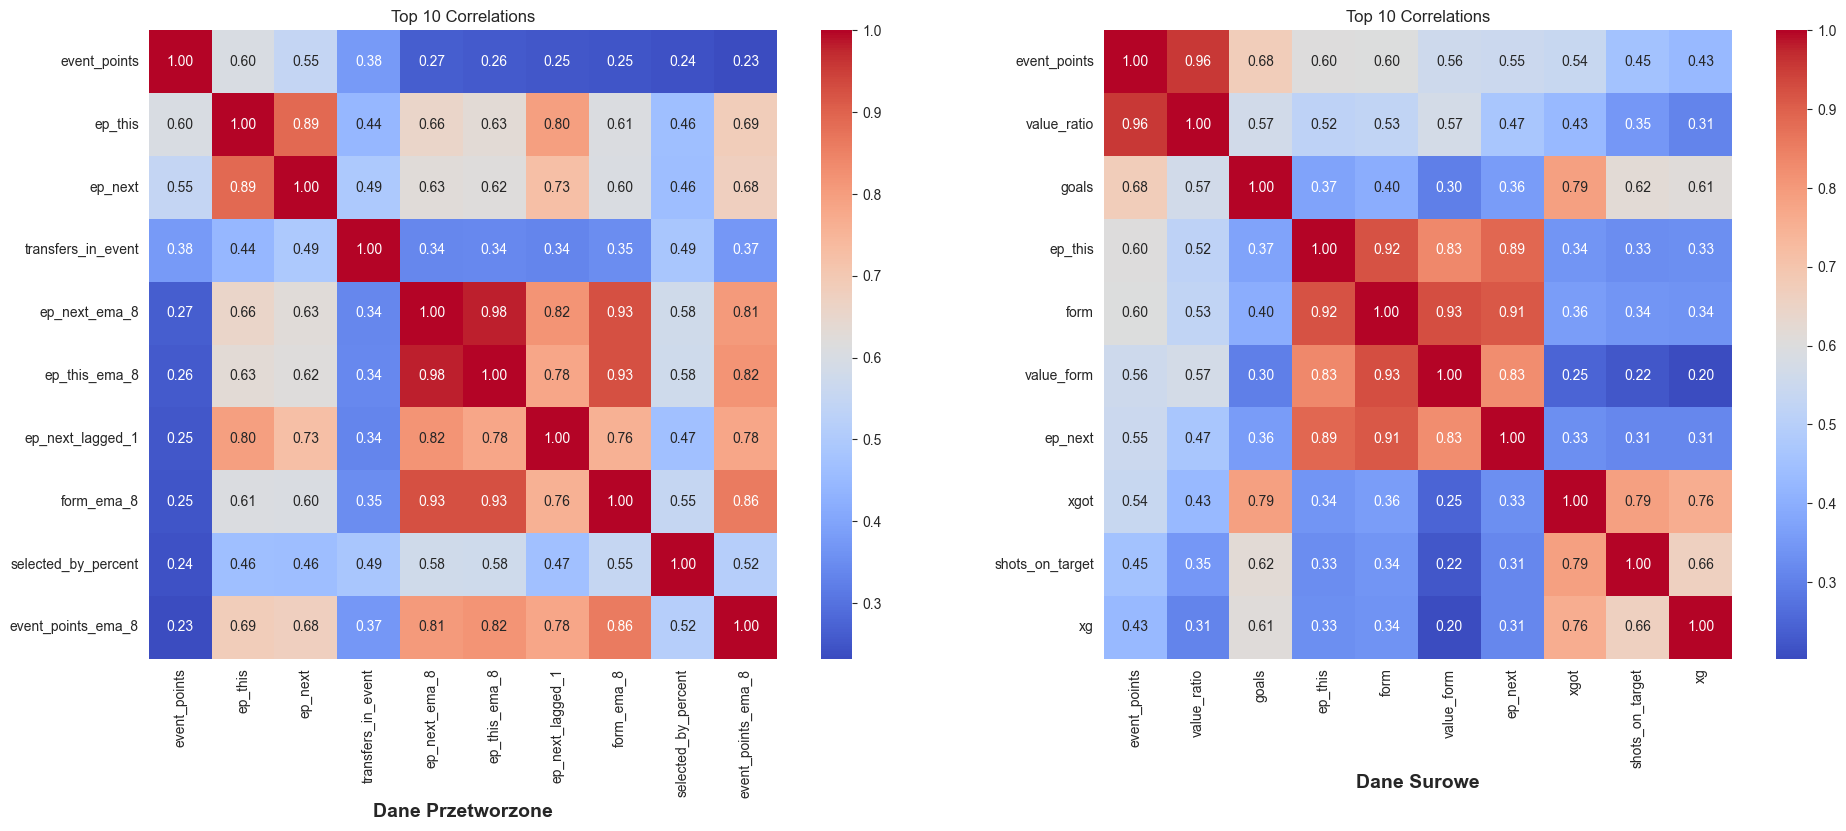

In [152]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr()["event_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lagged, data], ["Dane Przetworzone", "Dane Surowe"])

In [153]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs


In [154]:
pairs = over_corr_pairs(data_lagged, 0.95)
pairs

[('threat_ema_8', 'expected_goals_ema_8', 0.9547),
 ('threat_ema_8', 'expected_goal_involvements_lagged_1', 0.9556),
 ('transfers_out_lagged_1', 'transfers_out', 0.9664),
 ('creativity_lagged_1', 'expected_assists_lagged_1', 0.9562),
 ('threat_ema_8', 'expected_goal_involvements_ema_8', 0.9607),
 ('expected_goals_ema_8', 'expected_goal_involvements_ema_8', 0.9553),
 ('expected_goal_involvements_lagged_1',
  'expected_goal_involvements_ema_8',
  0.9938),
 ('chance_of_playing_this_round_ema_8',
  'chance_of_playing_next_round_ema_8',
  0.9854),
 ('bps_ema_8', 'bps_lagged_1', 0.9881),
 ('creativity_lagged_1', 'creativity_ema_8', 0.994),
 ('expected_assists_lagged_1', 'creativity_ema_8', 0.9507),
 ('creativity_lagged_1', 'expected_assists_ema_8', 0.9535),
 ('expected_assists_lagged_1', 'expected_assists_ema_8', 0.9922),
 ('creativity_ema_8', 'expected_assists_ema_8', 0.9588),
 ('value_season_ema_8', 'value_season_lagged_1', 0.9734),
 ('ep_next_ema_8', 'ep_this_ema_8', 0.9811),
 ('corners_a

In [155]:
[c for c in pre_game_cols if any(c == p[1] or c == p[0] for p in pairs)]

['cost_change_start', 'transfers_in', 'transfers_out']

In [176]:
worst_cols = data.select_dtypes(include=np.number).corr()["event_points"].abs()
lowest_corr_cols_to_drop = [c for c in worst_cols[worst_cols<.5].index if c not in cols_id+static_cols+pre_game_cols]

AttributeError: 'list' object has no attribute 'random'

In [157]:
len(pairs)

43

In [158]:
for col1, col2, _ in pairs:
    if col1 in data_lagged.columns and col2 in data_lagged.columns:
        data_lagged.drop(columns=col1, inplace=True)

In [159]:
data_lagged.drop(columns=[c for c in lowest_corr_cols_to_drop if c in data_lagged.columns], inplace=True)

In [160]:
data_lagged.shape

(20337, 158)

In [161]:
data_lagged.head()

,form_lagged_1,second_name,goals_conceded_lagged_1,accurate_passes_ema_8,final_third_passes_lagged_1,ep_this_lagged_1,form_ema_8,first_name,duels_won_ema_8,transfers_in_event_ema_8,team_name,accurate_crosses_lagged_1,tackles_won_percent_ema_8,ep_next_lagged_1,aerial_duels_won_ema_8,successful_dribbles_percent_ema_8,successful_dribbles_lagged_1,dribbled_past_ema_8,event_points_ema_8,blocks_lagged_1,xg_per_90_ema_8,transfers_in_event_lagged_1,match_id,was_home,xgot_ema_8,shots_on_target_lagged_1,ground_duels_won_lagged_1,touches_opposition_box_lagged_1,accurate_long_balls_percent_ema_8,xgot_faced_lagged_1,selected_by_percent_ema_8,high_claim_lagged_1,value_form_lagged_1,shots_on_target_ema_8,gw,transfers_out_event_lagged_1,big_chances_missed_ema_8,saves_lagged_1,gk_accurate_long_balls_lagged_1,assists_ema_8,transfers_out_event_ema_8,goals_prevented_ema_8,transfers_out,accurate_long_balls_ema_8,headed_clearances_ema_8,penalties_missed_lagged_1,value_form_ema_8,accurate_long_balls_lagged_1,successful_dribbles_ema_8,chance_of_playing_next_round_ema_8,interceptions_ema_8,bps_lagged_1,start_min_ema_8,goals_ema_8,team_code,team_goals_conceded_lagged_1,was_fouled_ema_8,xa_per_90_ema_8,duels_lost_ema_8,offsides_lagged_1,ep_this,expected_assists_ema_8,id,recoveries_ema_8,value_season_lagged_1,aerial_duels_won_lagged_1,start_min_lagged_1,gk_accurate_long_balls_ema_8,ep_this_ema_8,xa_lagged_1,total_shots_ema_8,xg_ema_8,minutes_played_ema_8,touches_lagged_1,finish_min_ema_8,corners_and_indirect_freekicks_order_lagged_1,dribbled_past_lagged_1,was_fouled_lagged_1,chances_created_lagged_1,penalties_missed_ema_8,ict_index_ema_8,selected_by_percent,event_points,value_ratio_ema_8,now_cost_ema_8,fouls_committed_lagged_1,position,transfers_in_event,expected_goals_conceded_lagged_1,penalties_scored_ema_8,touches_opposition_box_ema_8,transfers_out_event,clearances_ema_8,sweeper_actions_lagged_1,chance_of_playing_next_round_lagged_1,accurate_passes_percent_ema_8,total_shots_lagged_1,xgot_faced_ema_8,bonus_lagged_1,ground_duels_won_ema_8,ground_duels_won_percent_ema_8,web_name,assists_lagged_1,team_goals_conceded_ema_8,saves_ema_8,sweeper_actions_ema_8,selected_rank_ema_8,cost_change_event_ema_8,touches_ema_8,goals_lagged_1,cost_change_event,tackles_ema_8,tackles_lagged_1,player_code,big_chances_missed_lagged_1,now_cost_rank_lagged_1,minutes_played_lagged_1,high_claim_ema_8,chances_created_ema_8,transfers_out_ema_8,accurate_crosses_percent_ema_8,transfers_in_lagged_1,expected_goal_involvements_per_90_ema_8,clearances_lagged_1,season_id,finish_min_lagged_1,duels_lost_lagged_1,cost_change_start_lagged_1,xa_ema_8,goals_prevented_lagged_1,final_third_passes_ema_8,fouls_committed_ema_8,accurate_passes_lagged_1,accurate_crosses_ema_8,direct_freekicks_order_ema_8,xg_lagged_1,team_strength,blocks_ema_8,influence_lagged_1,headed_clearances_lagged_1,tackles_won_lagged_1,status,expected_goals_conceded_per_90_ema_8,offsides_ema_8,aerial_duels_won_percent_ema_8,tackles_won_ema_8,recoveries_lagged_1,ep_next,interceptions_lagged_1,gk_accurate_passes_ema_8,event_points_lagged_1,xgot_lagged_1,cost_change_event_lagged_1,duels_won_lagged_1,threat_lagged_1,dreamteam_count_ema_8,penalties_scored_lagged_1,penalties_order_lagged_1
0,0.0,Milner,0,0.000000,0,0.0,0.000000,James,0.000000,0.000000,Brighton,0,0.000000,0.0,0.0,0.000000,0,0.0,0.000000,0,0.000000,0,24-25-prem-everton-vs-brighton-&-hove-albion,False,0.0,0,0,0,0.000000,0.0,0.0,0,0.0,0.000000,1,0,0.0,0,0,0.0,0.000000,0.0,421,0.000000,0.0,0,0.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,36,0,0.000000,0.000000,0.000000,0,1.6,0.000000,134,0.000000,0.0,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0,0.0,0,0,0,0,0.0,0.000000,0.1,2,0.000000,0.0,0,MID,513,0.0,0.0,0.000000,421,0.000000,0,0,0.000000,0,0.0,0,0.000000,0.000000,Milner,0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0,0,0.000000,0,15157,0,0,0,0.0,0.000000,0.000000,0.000000,0,0.000000,0,2425,0,0,0,0.000000,0.0,0.000000,0.0,0,0.000000,0.0,0.0,3,0.000000,0.0,0,0,a,0.000000,0.0,

In [162]:
data_lagged = data_lagged[cols_id + static_cols + [c for c in data_lagged.columns if c not in cols_id+static_cols]]
data_lagged.was_home = data_lagged.was_home.astype(int)

In [163]:
len(data_lagged.columns),len(set(data_lagged.columns))

(158, 158)

In [164]:
try:
    data_lagged[pre_game_cols]
except KeyError as e:
    print(f"Nie można znaleźć kolumn: {e}")

Nie można znaleźć kolumn: "['cost_change_start', 'transfers_in'] not in index"


In [174]:
pre_game_cols = [c for c in pre_game_cols if c != "cost_change_start" and c != "transfers_in"]

In [175]:
pre_game_cols

['selected_by_percent',
 'cost_change_event',
 'transfers_out',
 'transfers_in_event',
 'transfers_out_event',
 'ep_this',
 'ep_next']

In [178]:
def duplicated_cols(df:pd.DataFrame)->list[str]:
    return df.columns[df.T.duplicated(keep=False)].tolist()


In [179]:
[c for c in data_lagged.columns if c not in set(data_lagged.columns)]

[]

In [180]:
dup_cols = duplicated_cols(data_lagged)

In [181]:
dup_cols

[]

In [182]:
data_lagged.to_parquet(config.FPL_DATA_PATH,
                index=False)